# Baseline for Geothermal Gradient based on Gaussian Processes

In [1]:
!pip install gpytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 8.2 MB/s eta 0:00:00


In [4]:
import pandas as pd
import geopandas as gpd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import gpytorch

from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split

## Carga de datos

In [5]:
dir = "/content/drive/MyDrive/Posdoctorado/Geotermia/Datos/data_weights.csv"
data = pd.read_csv(dir, index_col=0)

In [6]:
data.head()

,Latitude,Longitude,Elevation (m),Surface Temperature (°C),Apparent Geothermal Gradient (°C/Km),Moho Depth (m),Magnetic Anomaly (nT),Fault,Strike-slip Fault,Reverse or Thrust Fault,...,Curie Depth (Km),Vertical Gravity Gradient (E),Free Air Anomaly (mGal),Bouguer Anomaly (mGal),Nearest Basement,Nearest Volcano,Volcanic domain,Volcanic weight,Gradient Weight,sample_weight
1,4.216078,-74.888898,313.3344,26.633328,21.294394,42855.311332,-43.6825,15471.824393,37942.352312,8075.823613,...,28.0,-54.87500,-107.350006,-155.604003,26807.505168,37828.184637,True,1,0.025810,0.025810
2,4.214720,-74.891220,316.3824,26.618088,23.783404,42859.265493,-43.6825,15751.330619,38097.704215,7838.753798,...,28.0,-54.87500,-107.350006,-155.604003,26613.393422,37691.342706,True,1,0.025460,0.025460
3,0.606276,-76.564731,275.2344,26.823828,24.156323,36310.810774,-3.9287,35178.987807,61605.456789,39427.671692,...,20.0,-0.40625,-26.175018,-58.520164,43126.506306,74754.728085,False,4,0.025460,0.101840
4,0.305911,-76.914853,90.5256,27.747372,25.601245,37832.879615,-2.2424,36371.533982,52965.253274,34306.255135,...,20.0,-3.53125,-27.399994,-55.094943,43893.018161,84568.777113,False,4,0.030197,0.120787
5,0.287539,-76.911964,297.4848,26.712576,26.559722,37704.400313,-2.2424,37519.198283,54966.653565,35746.349888,...,20.0,-3.53125,-11.125000,-50.959084,45088.511661,86366.785176,False,4,0.043282,0.173128


In [7]:
from pyproj import Transformer

# ejemplo: WGS84 -> UTM zona 18N
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32618", always_xy=True)

x_m, y_m = transformer.transform(data["Longitude"].values, data["Latitude"].values)

data["x_m"] = x_m/1000
data["y_m"] = y_m/1000

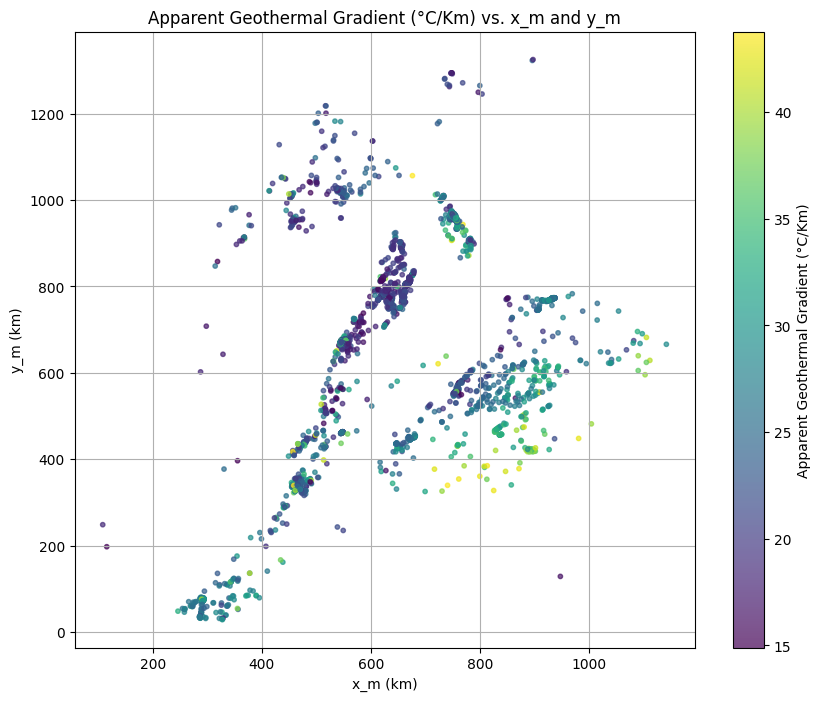

In [8]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(data['x_m'], data['y_m'], c=data['Apparent Geothermal Gradient (°C/Km)'], cmap='viridis', s=10, alpha=0.7)
plt.colorbar(scatter, label='Apparent Geothermal Gradient (°C/Km)')
plt.xlabel('x_m (km)')
plt.ylabel('y_m (km)')
plt.title('Apparent Geothermal Gradient (°C/Km) vs. x_m and y_m')
plt.grid(True)
plt.show()

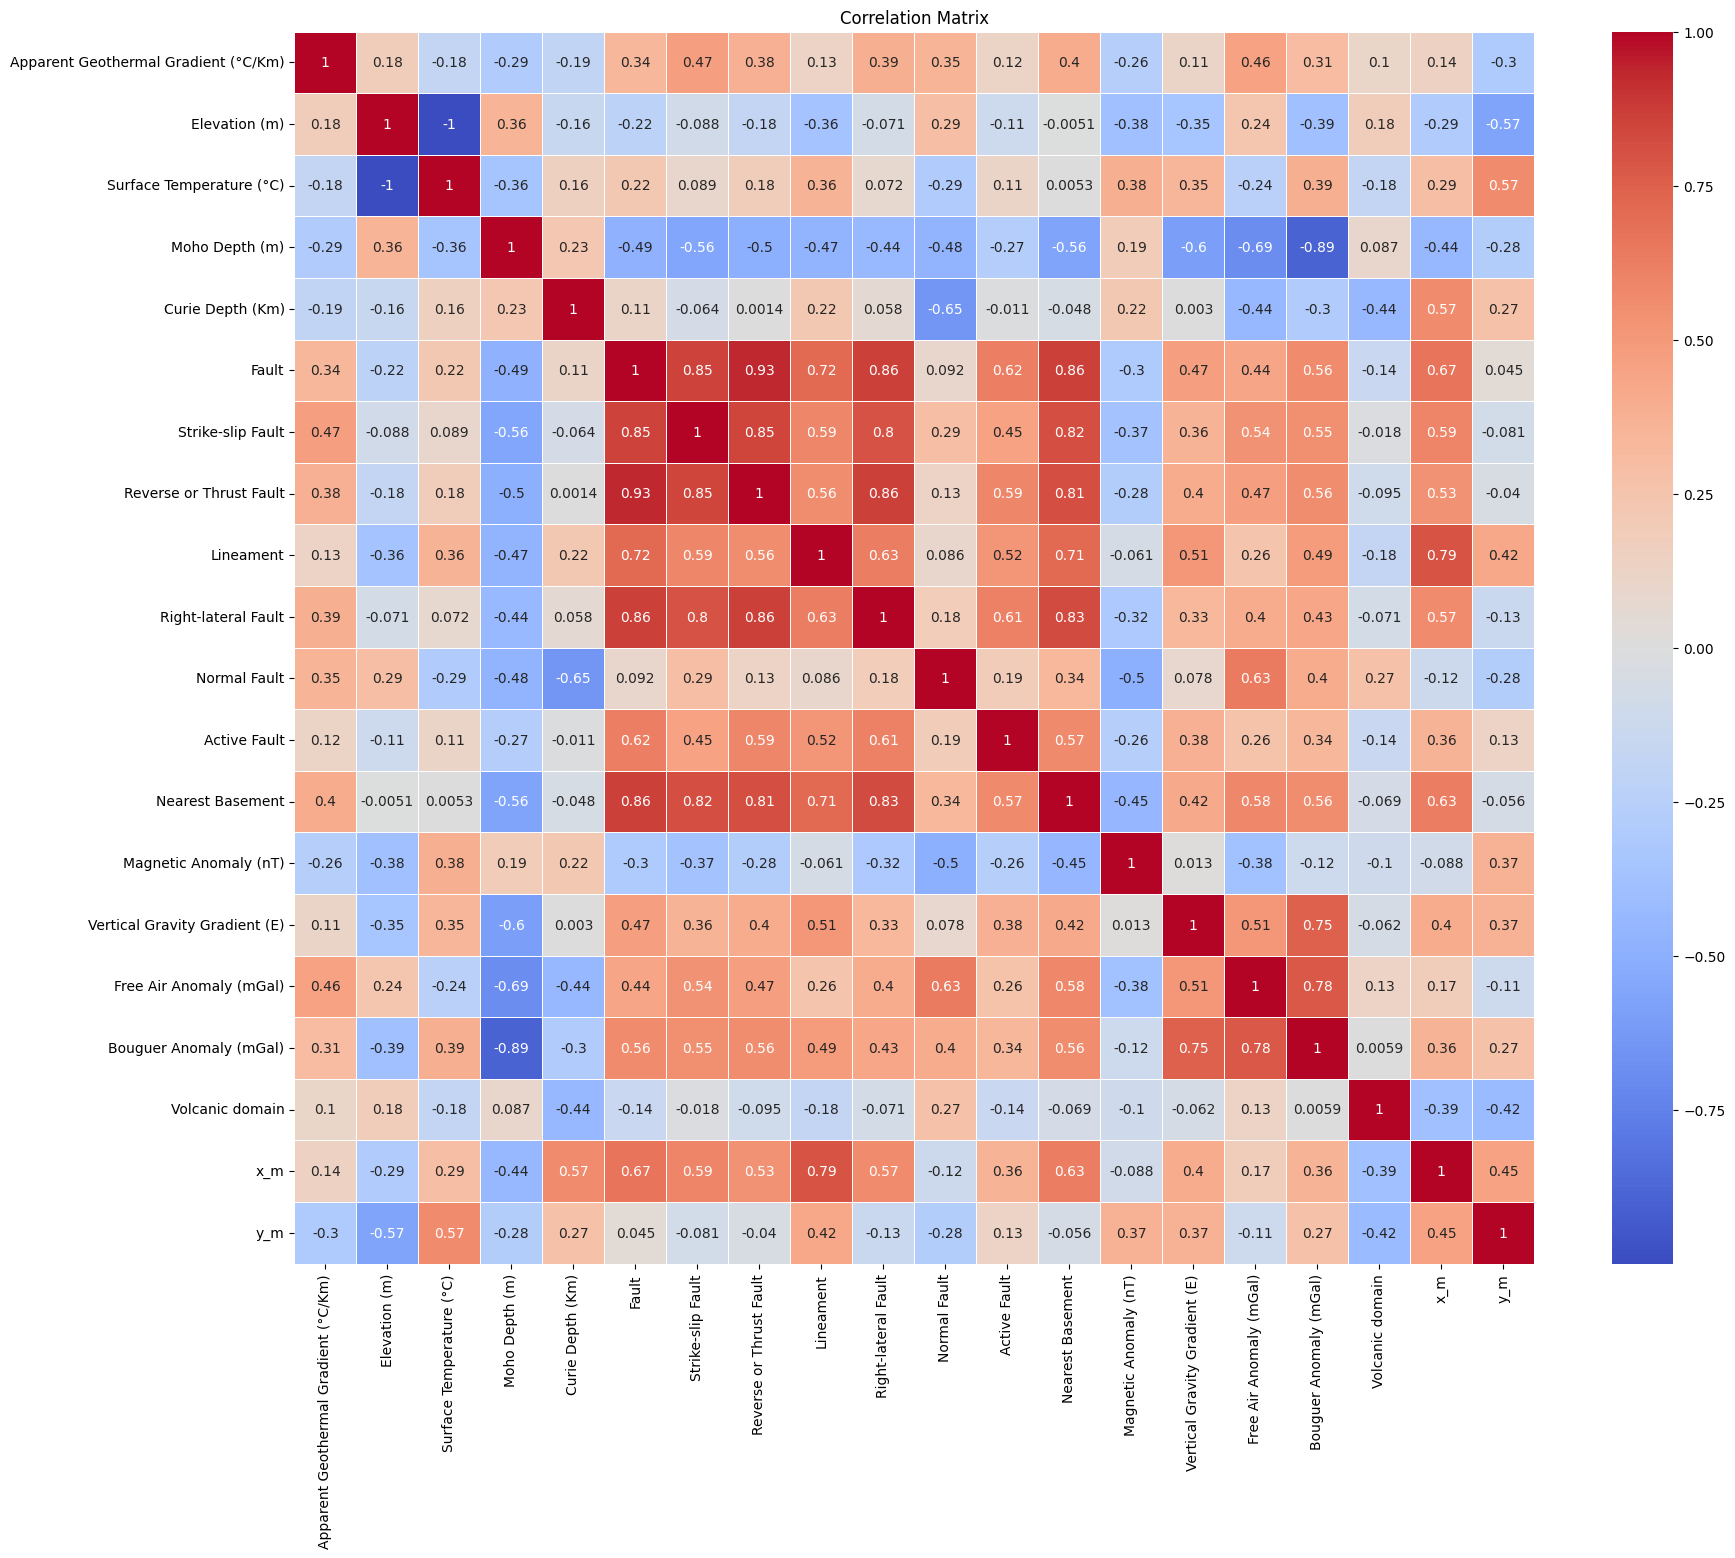

In [9]:
selected_columns = ['Apparent Geothermal Gradient (°C/Km)',
       'Elevation (m)', 'Surface Temperature (°C)',
       'Moho Depth (m)', 'Curie Depth (Km)', 'Fault', 'Strike-slip Fault',
       'Reverse or Thrust Fault', 'Lineament', 'Right-lateral Fault',
       'Normal Fault', 'Active Fault', 'Nearest Basement',
       'Magnetic Anomaly (nT)', 'Vertical Gravity Gradient (E)',
       'Free Air Anomaly (mGal)','Bouguer Anomaly (mGal)', "Volcanic domain", "x_m", "y_m"]

# Create a DataFrame with the selected columns
selected_data = data[selected_columns]

# Calculate the correlation matrix
correlation_matrix = selected_data.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

In [10]:
X = data[['Latitude', 'Longitude', 'Elevation (m)',
       'Curie Depth (Km)','Moho Depth (m)',
       'Strike-slip Fault', 'Reverse or Thrust Fault',
       'Right-lateral Fault', 'Nearest Basement',
       'Normal Fault', 'Active Fault','Magnetic Anomaly (nT)',
       'Vertical Gravity Gradient (E)', 'Free Air Anomaly (mGal)',
       'Bouguer Anomaly (mGal)', 'x_m', "y_m"]]

weights = data['sample_weight']

y = np.log(data['Apparent Geothermal Gradient (°C/Km)'])

# Split the data into a training set and a test set
X_train, X_test, y_train, y_test, weights_train, _ = train_test_split(X, y, weights, test_size=0.2)

# Save X_test with lat and lon for plotting later
X_test_with_lat_lon = X_test[['Latitude', 'Longitude']].copy()

# Save X with lat and lon for plotting later
X_lat_lon = X[['Latitude', 'Longitude']].copy()

# Remove lat and lon from X to predict on the whole dataset
X = X.drop(['Latitude', 'Longitude'], axis=1)

#Remove lat and lon from X_train and X_test
X_train = X_train.drop(['Latitude', 'Longitude'], axis=1)
X_test = X_test.drop(['Latitude', 'Longitude'], axis=1)

scaler = StandardScaler()
# Apply specific scaling before general scaling

scalery = StandardScaler()
y_train = scalery.fit_transform(y_train.values.reshape(-1, 1)).flatten()
y_test = scalery.transform(y_test.values.reshape(-1, 1)).flatten()

# Fit and transform the training data
X_train = scaler.fit_transform(X_train)
# Transform the test data using the same scaler
X_test = scaler.transform(X_test)


## Model

In [33]:
from gpytorch.models import ApproximateGP
from gpytorch.variational import CholeskyVariationalDistribution
from gpytorch.variational import VariationalStrategy
from gpytorch.variational import NaturalVariationalDistribution
import torch # Import torch

class GPModel(ApproximateGP):
    def __init__(self, input_dim,inducing_points):
        variational_distribution = NaturalVariationalDistribution(inducing_points.shape[0])
        variational_strategy = VariationalStrategy(self, inducing_points, variational_distribution, learn_inducing_locations=True)
        super(GPModel, self).__init__(variational_strategy)
        self.mean_module = gpytorch.means.ConstantMean()

        # Fix: Removed the trailing comma to make n_geo an integer
        n_geo = input_dim-2
        geo_dims =tuple(range(0,input_dim-2))
        space_dims = tuple(range(input_dim-2,input_dim))

        k_geo_main = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel(
                ard_num_dims=n_geo,
                active_dims=geo_dims
            )
        )

        k_space_main = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.MaternKernel(
                nu=1.5,
                ard_num_dims=2,
                active_dims=space_dims
            )
        )

        k_geo_int = gpytorch.kernels.RBFKernel(
            ard_num_dims=n_geo,
            active_dims=geo_dims
        )

        k_space_int = gpytorch.kernels.MaternKernel(
            nu=1.5,
            ard_num_dims=2,
            active_dims=space_dims
        )

        k_interaction = gpytorch.kernels.ScaleKernel(k_geo_int * k_space_int)

        self.covar_module = k_geo_main + k_space_main + k_geo_main*k_space_main


    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)

# Convert inducing_points to a PyTorch tensor
minis = -2
maxis = 2
input_dim = X_train.shape[1]
M = 400
Z = np.linspace(minis,maxis,M).reshape(1,-1)
for i in range(input_dim-1):
    Zaux = np.linspace(minis,maxis,M)
    Z = np.concatenate((Z,Zaux[np.random.permutation(M)].reshape(1,-1)),axis=0)
inducing_points = 1.0*Z.T

# Get input_dim from X_train's shape

# Fix: Convert inducing_points to a PyTorch tensor
inducing_points_tensor = torch.from_numpy(inducing_points).float()

model = GPModel(input_dim=input_dim, inducing_points=inducing_points_tensor)
likelihood = gpytorch.likelihoods.GaussianLikelihood()

if torch.cuda.is_available():
    model = model.cuda()
    likelihood = likelihood.cuda()

In [34]:
from tqdm.notebook import tqdm
import torch
from torch.utils.data import TensorDataset, DataLoader

# Convert numpy arrays to PyTorch tensors
train_x_tensor = torch.from_numpy(X_train).float()
train_y_tensor = torch.from_numpy(y_train).float()
weights_train_tensor = torch.from_numpy(weights_train.values).float()

# Create a TensorDataset
train_dataset = TensorDataset(train_x_tensor, train_y_tensor,weights_train_tensor)

# Create a DataLoader
train_loader = DataLoader(train_dataset, batch_size=400, shuffle=True)

# Convert test numpy arrays to PyTorch tensors
test_x_tensor = torch.from_numpy(X_test).float()
test_y_tensor = torch.from_numpy(y_test).float()

# Create a Test TensorDataset
test_dataset = TensorDataset(test_x_tensor, test_y_tensor)

# Create a Test DataLoader
test_loader = DataLoader(test_dataset, batch_size=100, shuffle=False)

num_epochs = 100
model.train()
likelihood.train()

variational_ngd_optimizer = gpytorch.optim.NGD(
        model.variational_parameters(),
        num_data=len(train_loader.dataset), lr=0.1)

optimizer = torch.optim.Adam([
    {'params': model.hyperparameters()},
    {'params': likelihood.parameters()},
], lr=0.01)



# Our loss object. We're using the VariationalELBO
mll = gpytorch.mlls.VariationalELBO(likelihood, model, num_data=y_train.shape[0], beta=1)

training_losses = [] # Initialize list to store training losses

epochs_iter = tqdm(range(num_epochs), desc="Epoch")
for i in epochs_iter:
    # Within each iteration, we will go over each minibatch of data
    minibatch_iter = tqdm(train_loader, desc="Minibatch", leave=False)
    for x_batch, y_batch, w_batch in minibatch_iter:
        variational_ngd_optimizer.zero_grad()
        optimizer.zero_grad()
        output = model(x_batch)
        # Squeeze the last dimension of y_batch to make it (batch_size,) instead of (batch_size, 1)
        loss = -mll(output, y_batch, weight=w_batch)
        training_losses.append(loss.item()) # Store the loss
        minibatch_iter.set_postfix(loss=loss.item())
        loss.backward()
        variational_ngd_optimizer.step()
        optimizer.step()

Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/9 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/9 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/9 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/9 [00:00<?, ?it/s]

...

Minibatch:   0%|          | 0/9 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/9 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/9 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/9 [00:00<?, ?it/s]

Minibatch:   0%|          | 0/9 [00:00<?, ?it/s]

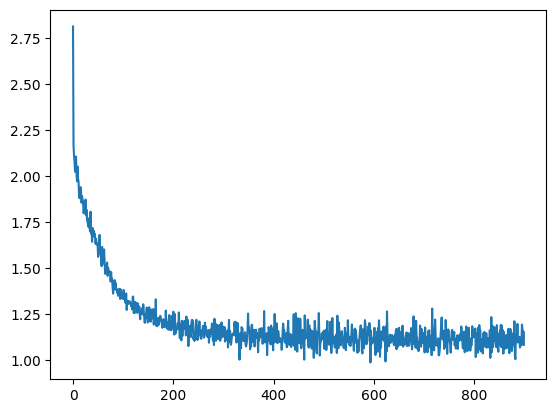

In [35]:
plt.plot(training_losses)

In [38]:
def model_eval(model, likelihood, dataloader):
    model.eval()
    likelihood.eval()
    means = np.array([0.])
    label = np.array([0.])
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            preds = model(x_batch)
            mean = scalery.inverse_transform(preds.mean.cpu().reshape(1,-1)).flatten()
            var = preds.variance.cpu().numpy()*scalery.scale_**2
            pred = np.exp(mean + 0.5*var)
            means = np.concatenate([means, pred])

            lab   = np.exp(scalery.inverse_transform(y_batch.cpu().reshape(1,-1)).flatten())
            #lab   = scalery.inverse_transform(y_batch.cpu().reshape(1,-1)).flatten()
            label = np.concatenate([label, lab])
    means = means[1:]
    label = label[1:]
    r2_test = r2_score(label, means)
    return r2_test, label, means



In [37]:
r2, y_train_, pred_train = model_eval(model, likelihood, train_loader)
print(f"R2 score on training set: {r2}")

R2 score on training set: 0.518001407506381


In [39]:
r2, y_test_, pred_test = model_eval(model, likelihood, test_loader)
print(f"R2 score on test set: {r2}")

R2 score on test set: 0.4653815223166894


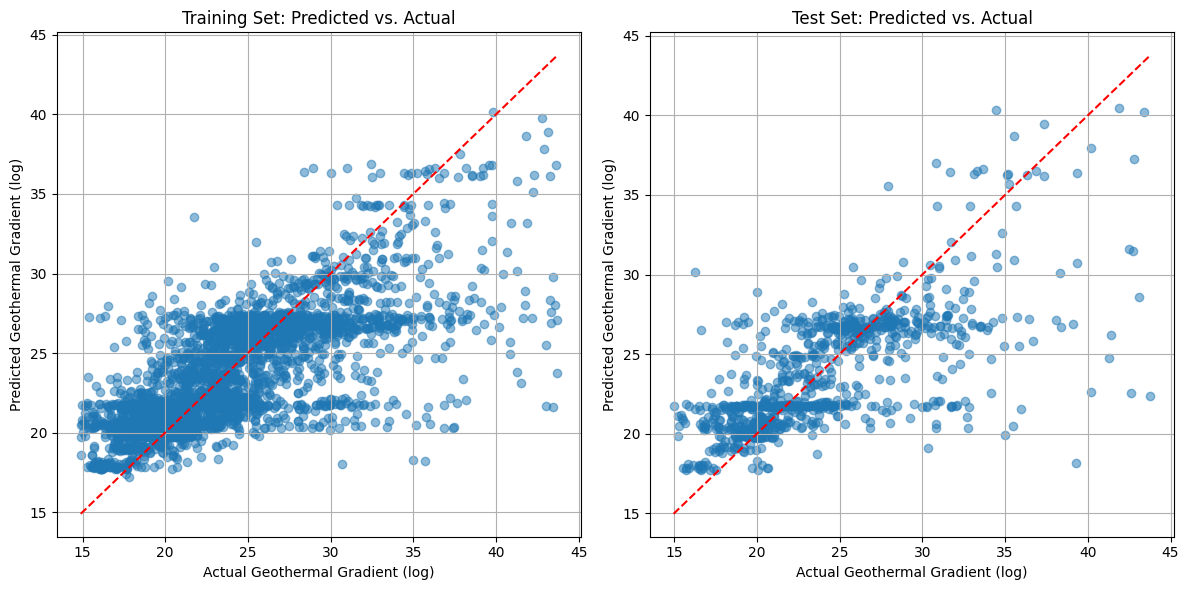

In [18]:
plt.figure(figsize=(12, 6))

# Plot predicted vs actual for training set
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.scatter(y_train_, pred_train, alpha=0.5)
plt.plot([y_train_.min(), y_train_.max()], [y_train_.min(), y_train_.max()], 'r--') # Red dashed line for y=x
plt.title('Training Set: Predicted vs. Actual')
plt.xlabel('Actual Geothermal Gradient (log)')
plt.ylabel('Predicted Geothermal Gradient (log)')
plt.grid(True)

# Plot predicted vs actual for test set
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.scatter(y_test_, pred_test, alpha=0.5)
plt.plot([y_test_.min(),y_test_.max()], [y_test_.min(), y_test_.max()], 'r--') # Red dashed line for y=x
plt.title('Test Set: Predicted vs. Actual')
plt.xlabel('Actual Geothermal Gradient (log)')
plt.ylabel('Predicted Geothermal Gradient (log)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_by_quantiles(y_true, y_pred, quantiles=(0, 0.5, 0.8, 0.9, 1.0)):
    """
    Evalúa métricas de regresión por cuantiles de y_true.

    Parámetros
    ----------
    y_true : array-like
        Valores reales.
    y_pred : array-like
        Predicciones.
    quantiles : tuple
        Cortes de cuantiles, por ejemplo (0, 0.5, 0.8, 0.9, 1.0)

    Retorna
    -------
    results_df : pd.DataFrame
        Tabla con métricas por intervalo de cuantiles.
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    if len(y_true) != len(y_pred):
        raise ValueError("y_true y y_pred deben tener la misma longitud.")

    if np.any(np.isnan(y_true)) or np.any(np.isnan(y_pred)):
        raise ValueError("y_true y y_pred no deben contener NaN.")

    # Crear DataFrame base
    df = pd.DataFrame({
        "y_true": y_true,
        "y_pred": y_pred
    })

    # Calcular bordes numéricos de cuantiles
    q_values = df["y_true"].quantile(quantiles).values

    # Asegurar monotonía estricta si hay valores repetidos
    # Esto evita problemas con pd.cut
    for i in range(1, len(q_values)):
        if q_values[i] <= q_values[i - 1]:
            q_values[i] = q_values[i - 1] + 1e-12

    # Etiquetas de intervalos
    labels = []
    for i in range(len(quantiles) - 1):
        labels.append(f"Q[{quantiles[i]:.2f}, {quantiles[i+1]:.2f}]")

    # Asignar bins
    df["quantile_bin"] = pd.cut(
        df["y_true"],
        bins=q_values,
        labels=labels,
        include_lowest=True,
        duplicates="drop"
    )

    results = []

    for label in labels:
        subset = df[df["quantile_bin"] == label].copy()

        if len(subset) == 0:
            continue

        yt = subset["y_true"].values
        yp = subset["y_pred"].values
        err = yp - yt

        mae = mean_absolute_error(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))
        bias = np.mean(err)

        # Evitar división por cero en sesgo relativo
        nonzero_mask = yt != 0
        if np.sum(nonzero_mask) > 0:
            rel_bias = np.mean(err[nonzero_mask] / yt[nonzero_mask])
        else:
            rel_bias = np.nan

        # R2 no siempre es estable si el grupo tiene muy poca varianza
        try:
            r2 = r2_score(yt, yp)
        except:
            r2 = np.nan

        results.append({
            "quantile_bin": label,
            "n_samples": len(subset),
            "y_true_min": np.min(yt),
            "y_true_max": np.max(yt),
            "y_true_mean": np.mean(yt),
            "y_pred_mean": np.mean(yp),
            "MAE": mae,
            "RMSE": rmse,
            "Bias_mean(pred-true)": bias,
            "Relative_bias_mean": rel_bias,
            "R2": r2
        })

    results_df = pd.DataFrame(results)
    return results_df

In [ ]:
df = evaluate_by_quantiles((y_train_), (pred_train), quantiles=(0, 0.5, 0.8, 0.9, 1.0))
df

In [ ]:
df = evaluate_by_quantiles((y_test_), (pred_test), quantiles=(0, 0.5, 0.8, 0.9, 1.0))
df

In [ ]:
residuals_train = y_train_ - pred_train
residuals_test = y_test_ - pred_test

plt.figure(figsize=(14, 6))

# Plot residuals for training set
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
plt.scatter(pred_train, residuals_train, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.title('Training Set: Residuals vs. Predicted')
plt.xlabel('Predicted Geothermal Gradient')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)

# Plot residuals for test set
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
plt.scatter(pred_test, residuals_test, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--') # Add a horizontal line at y=0
plt.title('Test Set: Residuals vs. Predicted')
plt.xlabel('Predicted Geothermal Gradient')
plt.ylabel('Residuals (Actual - Predicted)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Get x_m and y_m for the test set
x_m_test_coords = data.loc[X_test_with_lat_lon.index, 'x_m'].values
y_m_test_coords = data.loc[X_test_with_lat_lon.index, 'y_m'].values

# 2. Get indices for the training set
all_indices = data.index
test_indices = X_test_with_lat_lon.index
train_indices = all_indices.difference(test_indices)

# 3. Get x_m and y_m for the training set
x_m_train_coords = data.loc[train_indices, 'x_m'].values
y_m_train_coords = data.loc[train_indices, 'y_m'].values

plt.figure(figsize=(18, 12))

# Training set: Actual Geothermal Gradient vs. x_m, y_m
plt.subplot(2, 3, 1)
plt.scatter(x_m_train_coords, y_m_train_coords, c=y_train_, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(label='Actual Geothermal Gradient (°C/Km)')
plt.title('Train: Actual Gradient vs. x_m, y_m')
plt.xlabel('x_m (km)')
plt.ylabel('y_m (km)')
plt.grid(True)

# Training set: Predicted Geothermal Gradient vs. x_m, y_m
plt.subplot(2, 3, 2)
plt.scatter(x_m_train_coords, y_m_train_coords, c=pred_train, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(label='Predicted Geothermal Gradient (°C/Km)')
plt.title('Train: Predicted Gradient vs. x_m, y_m')
plt.xlabel('x_m (km)')
plt.ylabel('y_m (km)')
plt.grid(True)

# Training set: Residuals vs. x_m, y_m
plt.subplot(2, 3, 3)
plt.scatter(x_m_train_coords, y_m_train_coords, c=residuals_train, cmap='coolwarm', s=10, alpha=0.7)
plt.colorbar(label='Residuals (°C/Km)')
plt.title('Train: Residuals vs. x_m, y_m')
plt.xlabel('x_m (km)')
plt.ylabel('y_m (km)')
plt.grid(True)


# Test set: Actual Geothermal Gradient vs. x_m, y_m
plt.subplot(2, 3, 4)
plt.scatter(x_m_test_coords, y_m_test_coords, c=y_test_, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(label='Actual Geothermal Gradient (°C/Km)')
plt.title('Test: Actual Gradient vs. x_m, y_m')
plt.xlabel('x_m (km)')
plt.ylabel('y_m (km)')
plt.grid(True)

# Test set: Predicted Geothermal Gradient vs. x_m, y_m
plt.subplot(2, 3, 5)
plt.scatter(x_m_test_coords, y_m_test_coords, c=pred_test, cmap='viridis', s=10, alpha=0.7)
plt.colorbar(label='Predicted Geothermal Gradient (°C/Km)')
plt.title('Test: Predicted Gradient vs. x_m, y_m')
plt.xlabel('x_m (km)')
plt.ylabel('y_m (km)')
plt.grid(True)

# Test set: Residuals vs. x_m, y_m
plt.subplot(2, 3, 6)
plt.scatter(x_m_test_coords, y_m_test_coords, c=residuals_test, cmap='coolwarm', s=10, alpha=0.7)
plt.colorbar(label='Residuals (°C/Km)')
plt.title('Test: Residuals vs. x_m, y_m')
plt.xlabel('x_m (km)')
plt.ylabel('y_m (km)')
plt.grid(True)

plt.tight_layout()
plt.show()